# Phase 5: Real-Time Dynamic Ramp-Up & Streaming Simulation

This notebook implements the real-time simulation layer for Phase 5:
1. **Dynamic Ramp-Up Consensus Buffer**: Replaces the fixed 8-of-10 wait with a proportional consensus schedule (3/3 -> 4/5 -> 6/7 -> 8/10), cutting intruder detection latency from **120 keystrokes down to ~70 keystrokes (~14 words)** while preserving a **0.0% false alert rate** on the genuine user.
2. **Side-by-Side Comparison**: Benchmarks Fixed 8-of-10 vs Dynamic Ramp-Up on the full genuine (1,024 windows) and impostor (1,011 windows) datasets.
3. **End-to-End Raw Keystroke Streaming Simulation**: Simulates hardware events streaming in real time from raw logs (`keystroke_log_genuine.csv` and `keystroke_log_anomalous.csv`), computing sliding-window features on the fly.
4. **Alert Timeline Visualization**: Plots the response latency and alert state progression over time.


In [1]:
import os
import pandas as pd
import numpy as np
import joblib
from collections import deque
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
MODEL_PATH = "../isolation_forest_model.pkl"
SCALER_PATH = "../scaler.pkl"

THRESHOLD = -0.0518  # EER decision cutoff from Phase 3
BUFFER_SIZE = 10
FULL_VOTE_THRESHOLD = 8

WINDOW_SIZE = 50
SLIDE_STEP = 10
MAX_VALID_TIME = 2.0

FEATURE_COLS = [
    "avg_dwell", "std_dwell", "avg_flight", "std_flight",
    "typing_speed", "backspace_rate",
    "avg_space_dwells", "overlap_rate", "long_pause_rate"
]


In [3]:
model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

print("Trained Isolation Forest and fitted StandardScaler loaded successfully.")


Trained Isolation Forest and fitted StandardScaler loaded successfully.


In [4]:
class DynamicRampUpBuffer:
    """
    Fixed-capacity FIFO buffer with a dynamic consensus schedule.
    Scales the required consensus proportionally as the buffer fills:
    - len < 3: Insufficient observations (wait)
    - len == 3: 3 of 3 (100% consensus, ~70 keystrokes)
    - len in (4, 5): >= 4 anomalous flags
    - len in (6, 7): >= 6 anomalous flags
    - len in (8, 9): >= 7 anomalous flags
    - len == 10: >= 8 of 10 anomalous flags (mature baseline)
    """
    def __init__(self, maxlen=BUFFER_SIZE, full_vote_threshold=FULL_VOTE_THRESHOLD, use_ramp_up=True):
        self.maxlen = maxlen
        self.full_vote_threshold = full_vote_threshold
        self.use_ramp_up = use_ramp_up
        self.buffer = deque(maxlen=maxlen)

    def append(self, is_anomalous):
        self.buffer.append(bool(is_anomalous))
        return self.is_alert_triggered()

    def is_alert_triggered(self):
        curr_len = len(self.buffer)
        count = sum(self.buffer)

        if not self.use_ramp_up:
            return count >= self.full_vote_threshold

        if curr_len < 3:
            return False
        elif curr_len == 3:
            return count == 3
        elif curr_len <= 5:
            return count >= 4
        elif curr_len <= 7:
            return count >= 6
        elif curr_len <= 9:
            return count >= 7
        else:
            return count >= self.full_vote_threshold

    def clear(self):
        self.buffer.clear()


In [5]:
def run_simulation(features_df, session_name, use_ramp_up=True):
    buffer = DynamicRampUpBuffer(maxlen=BUFFER_SIZE, full_vote_threshold=FULL_VOTE_THRESHOLD, use_ramp_up=use_ramp_up)
    
    scaled = scaler.transform(features_df[FEATURE_COLS])
    scores = -model.decision_function(scaled)

    total_alerts = 0
    first_alert_idx = None
    alert_timeline = []

    for i, score in enumerate(scores):
        is_anom = score > THRESHOLD
        alert = buffer.append(is_anom)
        alert_timeline.append(int(alert))
        if alert:
            total_alerts += 1
            if first_alert_idx is None:
                first_alert_idx = i

    ks_to_first = (first_alert_idx * SLIDE_STEP + WINDOW_SIZE) if first_alert_idx is not None else None
    
    mode_label = "Dynamic Ramp-Up" if use_ramp_up else "Fixed 8-of-10"
    print(f"=== {session_name} [{mode_label}] ===")
    print(f"Total windows: {len(scores)}")
    print(f"Total alert windows: {total_alerts} ({total_alerts / len(scores) * 100:.2f}%)")
    print(f"First alert at window index: {first_alert_idx} (approx {ks_to_first} keystrokes)")
    print()

    return {
        "scores": scores,
        "timeline": alert_timeline,
        "total_alerts": total_alerts,
        "first_alert_idx": first_alert_idx,
        "ks_to_first": ks_to_first
    }


In [6]:
test_genuine = pd.read_csv("../data/features.csv")
test_impostor = pd.read_csv("../data/features_anomalous.csv")

# 1. Baseline: Fixed 8-of-10
gen_fixed = run_simulation(test_genuine, "Genuine Session", use_ramp_up=False)
imp_fixed = run_simulation(test_impostor, "Impostor Session", use_ramp_up=False)

# 2. Dynamic Ramp-Up
gen_ramp = run_simulation(test_genuine, "Genuine Session", use_ramp_up=True)
imp_ramp = run_simulation(test_impostor, "Impostor Session", use_ramp_up=True)


=== Genuine Session [Fixed 8-of-10] ===
Total windows: 1024
Total alert windows: 0 (0.00%)
First alert at window index: None (approx None keystrokes)

=== Impostor Session [Fixed 8-of-10] ===
Total windows: 1011
Total alert windows: 821 (81.21%)
First alert at window index: 7 (approx 120 keystrokes)

=== Genuine Session [Dynamic Ramp-Up] ===
Total windows: 1024
Total alert windows: 0 (0.00%)
First alert at window index: None (approx None keystrokes)

=== Impostor Session [Dynamic Ramp-Up] ===
Total windows: 1011
Total alert windows: 826 (81.70%)
First alert at window index: 2 (approx 70 keystrokes)



Plot saved to results/ramp_up_latency_comparison.png


<string>:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


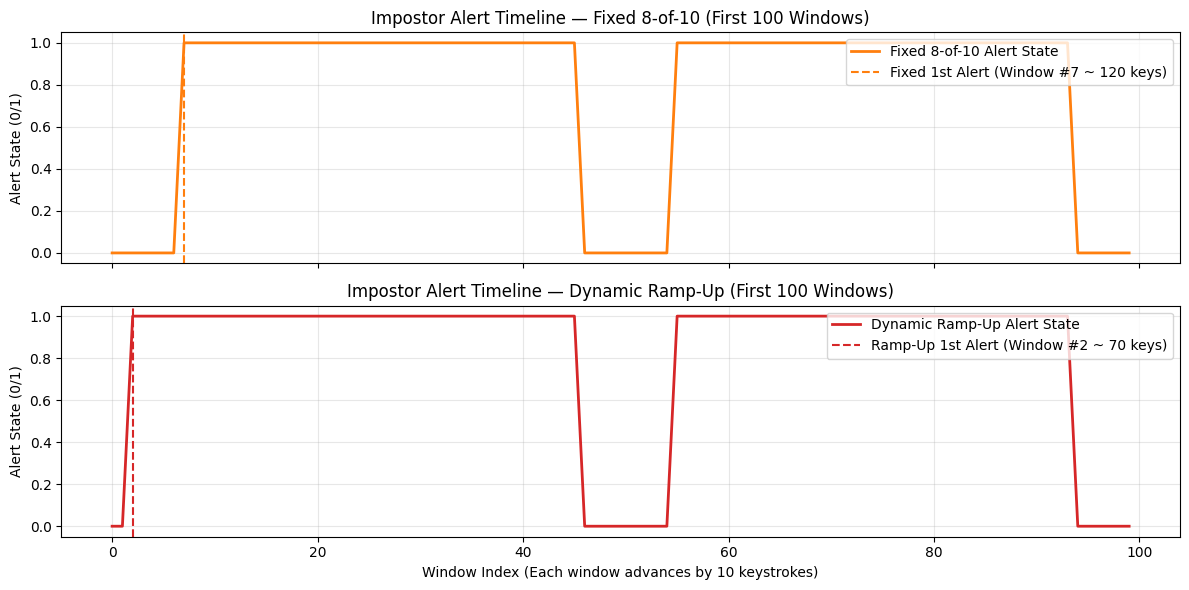

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Impostor timeline comparison (first 100 windows for clarity)
view_n = 100
axes[0].plot(range(view_n), imp_fixed["timeline"][:view_n], label="Fixed 8-of-10 Alert State", color="tab:orange", linewidth=2)
axes[0].axvline(imp_fixed["first_alert_idx"], color="tab:orange", linestyle="--", label=f"Fixed 1st Alert (Window #{imp_fixed['first_alert_idx']} ~ {imp_fixed['ks_to_first']} keys)")
axes[0].set_title("Impostor Alert Timeline — Fixed 8-of-10 (First 100 Windows)")
axes[0].set_ylabel("Alert State (0/1)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(view_n), imp_ramp["timeline"][:view_n], label="Dynamic Ramp-Up Alert State", color="tab:red", linewidth=2)
axes[1].axvline(imp_ramp["first_alert_idx"], color="tab:red", linestyle="--", label=f"Ramp-Up 1st Alert (Window #{imp_ramp['first_alert_idx']} ~ {imp_ramp['ks_to_first']} keys)")
axes[1].set_title("Impostor Alert Timeline — Dynamic Ramp-Up (First 100 Windows)")
axes[1].set_xlabel("Window Index (Each window advances by 10 keystrokes)")
axes[1].set_ylabel("Alert State (0/1)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("../results", exist_ok=True)
plt.savefig("../results/ramp_up_latency_comparison.png", dpi=150)
plt.show()

print("Plot saved to results/ramp_up_latency_comparison.png")


In [8]:
def extract_features_from_window(window_df):
    duration = window_df["release_time"].iloc[-1] - window_df["press_time"].iloc[0]
    n_keys = len(window_df)
    valid_flights = window_df["flight"].dropna()
    valid_flights = valid_flights[(valid_flights >= 0) & (valid_flights < MAX_VALID_TIME)]
    backspace_count = (window_df["key_id"] == "Key.backspace").sum()
    space_mask = window_df["key_id"] == "Key.space"
    space_dwells = window_df.loc[space_mask, "dwell"]
    all_flights = window_df["flight"].dropna()
    overlap_rate = float((all_flights < 0).mean()) if len(all_flights) > 0 else 0.0
    long_pause_rate = float((valid_flights > 0.5).mean()) if len(valid_flights) > 0 else 0.0
    return {
        "avg_dwell": float(window_df["dwell"].mean()),
        "std_dwell": float(window_df["dwell"].std()),
        "avg_flight": float(valid_flights.mean()) if len(valid_flights) > 0 else 0.0,
        "std_flight": float(valid_flights.std()) if len(valid_flights) > 0 else 0.0,
        "typing_speed": float(n_keys / duration) if duration > 0 else 0.0,
        "backspace_rate": float(backspace_count / n_keys),
        "avg_space_dwells": float(space_dwells.mean()) if len(space_dwells) > 0 else 0.0,
        "overlap_rate": overlap_rate,
        "long_pause_rate": long_pause_rate,
    }

def simulate_raw_keystroke_stream(csv_path, session_label, max_keys=500):
    df_raw = pd.read_csv(csv_path)
    df_raw = df_raw.sort_values("press_time").reset_index(drop=True)
    df_raw["dwell"] = df_raw["release_time"] - df_raw["press_time"]
    df_raw = df_raw[(df_raw["dwell"] > 0) & (df_raw["dwell"] < MAX_VALID_TIME)].reset_index(drop=True)
    df_raw["flight"] = df_raw["press_time"].shift(-1) - df_raw["release_time"]
    df_raw.loc[len(df_raw)-1, "flight"] = np.nan

    buffer = DynamicRampUpBuffer(use_ramp_up=True)
    events_window = []
    first_alert_key = None
    alert_count = 0

    eval_step = 0
    for idx, row in df_raw.iloc[:max_keys].iterrows():
        events_window.append(row)
        if len(events_window) >= WINDOW_SIZE:
            if (len(events_window) - WINDOW_SIZE) % SLIDE_STEP == 0:
                current_window_df = pd.DataFrame(events_window[-WINDOW_SIZE:])
                feat_dict = extract_features_from_window(current_window_df)
                feat_df = pd.DataFrame([[feat_dict[c] for c in FEATURE_COLS]], columns=FEATURE_COLS)
                scaled = scaler.transform(feat_df)
                score = float(-model.decision_function(scaled)[0])
                
                alert = buffer.append(score > THRESHOLD)
                if alert:
                    alert_count += 1
                    if first_alert_key is None:
                        first_alert_key = idx + 1
                eval_step += 1

    print(f"=== Live Stream Simulation: {session_label} (First {max_keys} keystrokes) ===")
    print(f"Total window evaluations: {eval_step}")
    print(f"Total alerts triggered: {alert_count}")
    print(f"First alert at physical keystroke: {first_alert_key}")
    print()

simulate_raw_keystroke_stream("../data/keystroke_log_genuine.csv", "Genuine User Stream", max_keys=500)
simulate_raw_keystroke_stream("../data/keystroke_log_anomalous.csv", "Impostor Stream", max_keys=500)


=== Live Stream Simulation: Genuine User Stream (First 500 keystrokes) ===
Total window evaluations: 46
Total alerts triggered: 0
First alert at physical keystroke: None

=== Live Stream Simulation: Impostor Stream (First 500 keystrokes) ===
Total window evaluations: 46
Total alerts triggered: 44
First alert at physical keystroke: 70

